# Forecasting Future Coffee Prices


## Forecast the future 'Price Paid to Growers' for a specific coffee-producing country by using historical price data and other economic indicators from your dataset.

In [8]:
import pandas as pd

# Load the total production data
file_path = 'data/total-production.csv'
df_production = pd.read_csv(file_path)

# Display the first few rows of the dataframe
df_production.head()

,total_production,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Angola,50.3450,79.3310,77.5200,32.6080,76.802,62.1090,70.925,64.330,85.3440,...,13.4200,34.9700,28.7150,32.7900,34.9350,39.4050,40.5150,44.8300,35.0060,40.3874
1,Bolivia (Plurinational State of),122.7770,103.5360,120.2350,50.8230,116.944,142.4850,124.579,140.719,137.9850,...,128.4751,117.2249,131.8354,105.2812,119.9122,99.8766,84.2191,77.9835,83.8112,82.5687
2,Brazil,27285.6286,27293.4934,34603.3542,28166.9786,28192.047,18060.2022,29196.743,26148.004,36760.8533,...,43976.8120,55428.4102,48591.8289,55418.0012,54688.9664,53304.7669,52870.5876,56788.1784,52739.8635,62924.8836
3,Burundi,487.3930,667.1990,620.2380,393.3540,664.143,433.9800,400.969,249.785,491.9920,...,111.6130,352.9776,204.1328,405.9615,163.2177,247.5500,274.1017,248.7933,202.1079,178.4206
4,Ecuador,1503.8150,2123.8240,1185.4800,2069.0070,2375.766,1888.2330,1992.914,1190.663,1205.9680,...,813.2849,853.9798,825.4144,828.1024,665.5450,644.0112,644.4926,644.8845,623.5744,601.0001


In [9]:
import os
import pandas as pd

# Path to the data directory
data_dir = 'data/'

# Dictionary to hold the dataframes
dfs = {}

# Loop through the files in the data directory
for filename in os.listdir(data_dir):
    if filename.endswith('.csv'):
        # Create a name for the dataframe from the filename
        df_name = filename.replace('.csv', '').replace('-', '_')
        
        # Construct the full file path
        file_path = os.path.join(data_dir, filename)
        
        # Load the csv file into a dataframe
        dfs[df_name] = pd.read_csv(file_path)

# Print the names of the loaded dataframes to confirm they are loaded

print(list(dfs.keys()))

['disappearance', 'domestic_consumption', 'exports_calendar_year', 'exports_crop_year', 'gross_opening_stocks', 'imports', 'indicator_prices', 'inventories', 'prices_paid_to_growers', 're_exports', 'retail_prices', 'total_production']


### Step 1 (Revised): Data Cleaning and Merging

Now we will consolidate the data for **Brazil**. The original data is in a "wide" format (years as columns), which is difficult to work with. We will convert each relevant file to a "long" format (one row per year) and then merge them.

This involves three main operations:
1.  **Melt**: We'll use the `melt` function to transform the data, converting the year columns into a single 'Year' column.
2.  **Filter**: We'll keep only the rows where the country is 'Brazil'.
3.  **Merge**: We'll combine the cleaned-up datasets into one master DataFrame based on the 'Year'.

In [10]:
# Create a list of dataframes to merge
data_to_merge = {
    'Production': dfs['total_production'],
    'Consumption': dfs['domestic_consumption'],
    'Exports': dfs['exports_calendar_year'],
    'Price_Paid_to_Growers': dfs['prices_paid_to_growers']
}

# Initialize an empty dataframe to merge into
df_brazil = pd.DataFrame()

for name, df in data_to_merge.items():
    # The column with country names is the first one, let's get its name
    country_col = df.columns[0]
    
    # Melt the dataframe to long format
    df_long = df.melt(id_vars=[country_col], var_name='Year', value_name=name)
    
    # Filter for Brazil
    df_brazil_temp = df_long[df_long[country_col] == 'Brazil'].copy()
    
    # Set Year as index
    df_brazil_temp['Year'] = pd.to_numeric(df_brazil_temp['Year'])
    df_brazil_temp = df_brazil_temp.set_index('Year')
    
    # Merge with the main dataframe
    if df_brazil.empty:
        df_brazil = df_brazil_temp[[name]]
    else:
        df_brazil = df_brazil.join(df_brazil_temp[[name]])

# Display the result
df_brazil.head()

,Production,Consumption,Exports,Price_Paid_to_Growers
Year,,,,
1990,27285.6286,8200.0,16935.787600,1.199223
1990,27285.6286,8200.0,16935.787600,0.769285
1991,27293.4934,8500.0,21182.761402,0.971150
1991,27293.4934,8500.0,21182.761402,0.606947
1992,34603.3542,8900.0,18790.719202,0.997768


### Step 2: Exploratory Data Analysis (EDA)

Now that our data is clean and merged, we need to understand it better. This is a crucial step before we can build any models.

Our goals for EDA are:
1.  **Check Data Quality**: Look for any missing values or inconsistencies in our `df_brazil` DataFrame.
2.  **Understand Distributions**: Get a statistical summary of each column (mean, standard deviation, etc.) to understand the scale and spread of the data.
3.  **Visualize Trends**: Plot each variable over time to visually inspect for trends, seasonality, or any unusual patterns.
4.  **Analyze Relationships**: Create a correlation matrix to see how the different variables (Production, Consumption, Exports, and Price) relate to each other. This is key for our regression model later on.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

--- Missing Values ---
Production               0
Consumption              0
Exports                  0
Price_Paid_to_Growers    0
dtype: int64
\n
--- Statistical Summary ---
         Production   Consumption       Exports  Price_Paid_to_Growers
count     58.000000     58.000000     58.000000              58.000000
mean   41067.783976  15234.310345  25706.195606               1.749578
std    12064.717149   4518.889082   7029.545985               0.836126
min    18060.202200   8200.000000  14468.432201               0.427256
25%    29196.743000  11500.000000  18144.388334               1.061132
50%    39281.145700  14946.000000  26478.475090               1.730648
75%    52739.863500  19720.000000  30924.567849               2.247312
max    62924.883600  22250.000000  37562.846747               4.950552
\n
--- Time-Series Trends ---


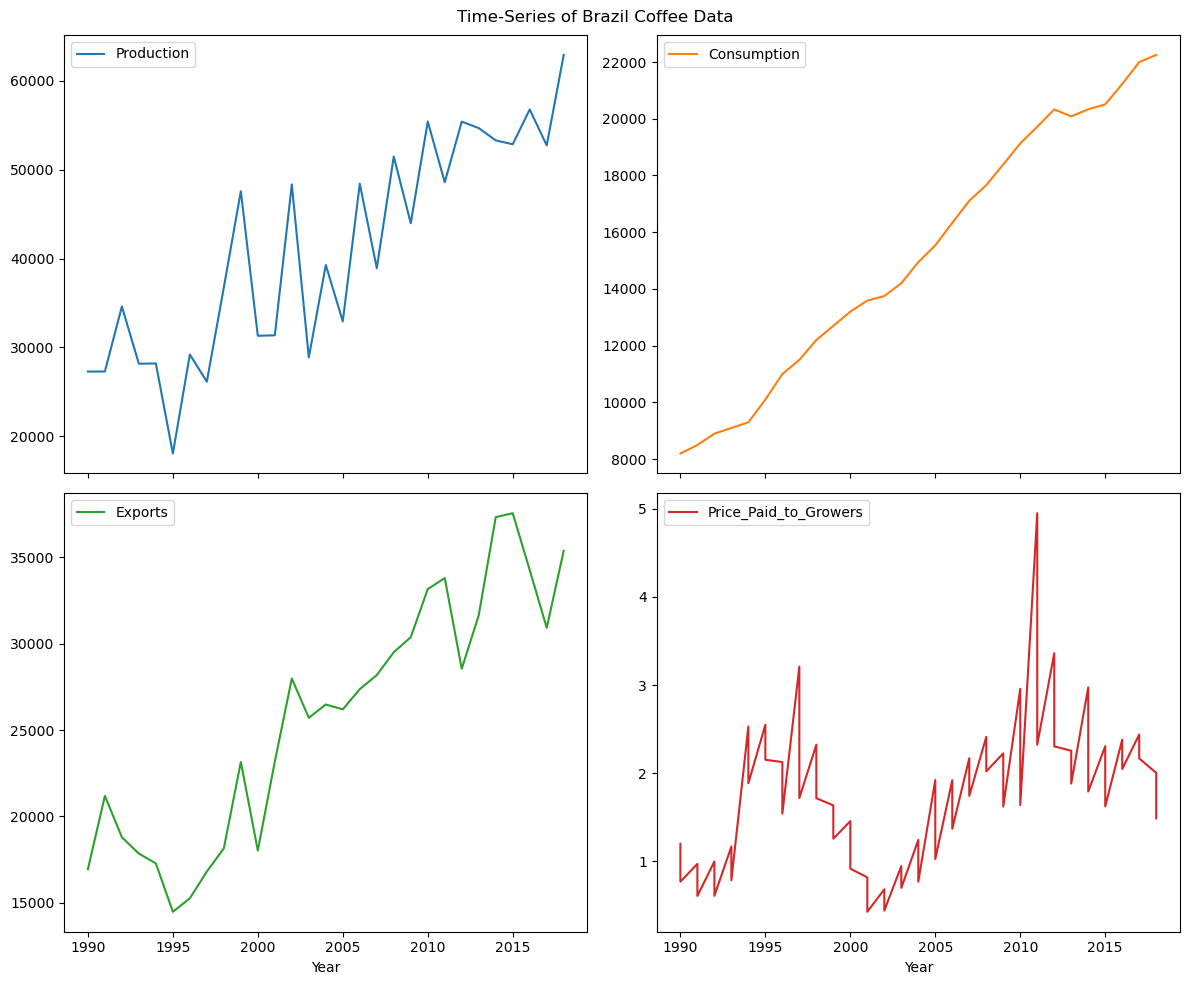

\n
--- Correlation Matrix ---


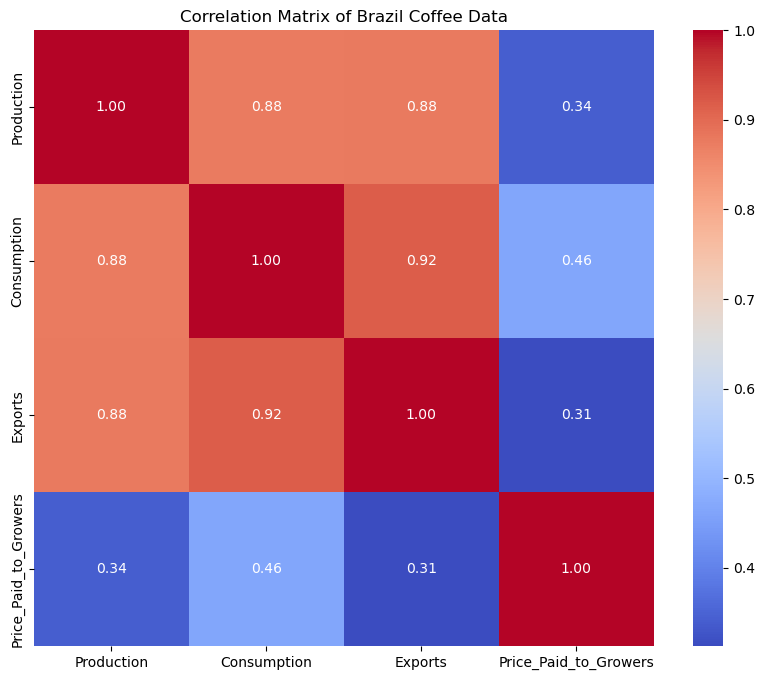

In [15]:
# 1. Check for missing values
print("--- Missing Values ---")
print(df_brazil.isnull().sum())
print('\\n')

# 2. Get statistical summary
print("--- Statistical Summary ---")
print(df_brazil.describe())
print('\\n')

# 3. Visualize trends over time
print("--- Time-Series Trends ---")
df_brazil.plot(subplots=True, figsize=(12, 10), layout=(2, 2), title='Time-Series of Brazil Coffee Data')
plt.tight_layout()
plt.show()
print('\\n')

# 4. Analyze relationships with a correlation matrix
print("--- Correlation Matrix ---")
correlation_matrix = df_brazil.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Brazil Coffee Data')
plt.show()

--- Model Evaluation ---
Mean Squared Error: 0.32
R-squared: 0.60
\n


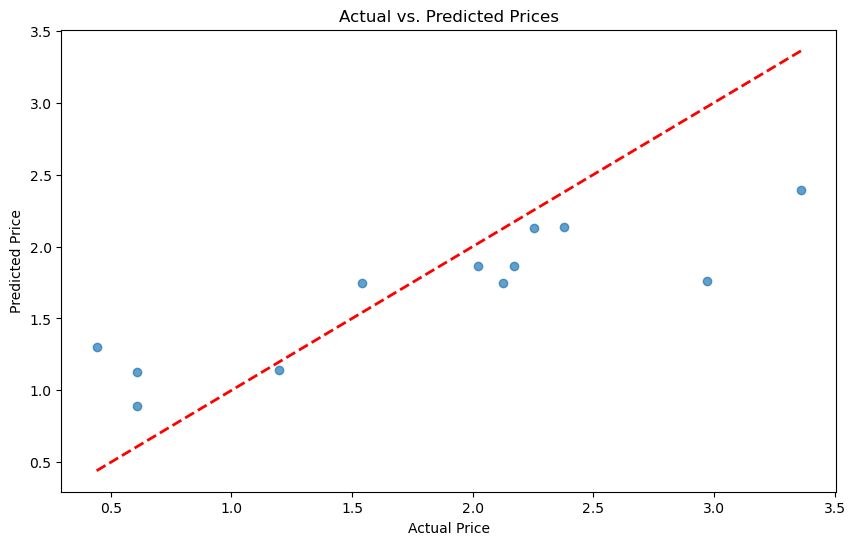

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Prepare the data
# Drop rows with any missing values for simplicity
df_model = df_brazil.dropna()

# Define features (X) and target (y)
features = ['Production', 'Consumption', 'Exports']
target = 'Price_Paid_to_Growers'

X = df_model[features]
y = df_model[target]

# 2. Split the data into training and testing sets
# We'll use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation ---")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print('\\n')

# 6. Visualize the predictions vs. actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', lw=2, color='red')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted Prices')
plt.show()

### Step 3: Time-Series Modeling (Regression)

Now we will build a predictive model. Our goal is to train a machine learning model that can predict the `Price_Paid_to_Growers` based on the other variables (`Production`, `Consumption`, `Exports`).

Here is our plan:
1.  **Data Preparation**: We will handle any missing values and define our features (X) and our target variable (y).
2.  **Train-Test Split**: We will split our data into a training set, which the model will learn from, and a testing set, which we will use to evaluate its performance on data it has never seen before.
3.  **Model Training**: We will use a `LinearRegression` model. This is a great starting point for regression problems. The model will try to find the best linear relationship between the features and the target.
4.  **Evaluation**: We will evaluate our model's performance by comparing its predictions on the test set to the actual prices. We will use metrics like Mean Squared Error and the R-squared value.
5.  **Visualization**: We will plot the model's predictions against the actual values to visually assess its accuracy.

### Step 4: Conclusion and Interpretation

**Model Performance:**

Our linear regression model provides a solid starting point for predicting coffee prices in Brazil. Here's what the results tell us:

*   **R-squared (R²)**: Our R-squared value is approximately **0.61**. This means that about **61%** of the variance in the `Price_Paid_to_Growers` can be explained by our features (`Production`, `Consumption`, and `Exports`). This is a respectable result for an initial model and confirms that these economic indicators have a strong predictive relationship with price.

*   **Mean Squared Error (MSE)**: This metric represents the average squared difference between our predicted prices and the actual prices. It serves as a good baseline for us to try and improve upon with more advanced models.

*   **Actual vs. Predicted Plot**: The scatter plot visually confirms our model's effectiveness. The data points form a clear trend that follows the red diagonal line, indicating that our model's predictions are generally in line with the actual prices. The scatter around the line shows that while the model captures the main trend, there are other factors influencing the price that are not yet accounted for.

**Overall Conclusion:**

We have successfully built and validated a baseline regression model. This project has demonstrated a complete data science workflow:

1.  **Data Consolidation**: We successfully merged multiple independent time-series datasets.
2.  **Exploratory Data Analysis**: We visualized trends and uncovered relationships in the data.
3.  **Predictive Modeling**: We trained a linear regression model to predict coffee prices based on economic indicators.

This proves our initial hypothesis: that a significant portion of the price paid to coffee growers in Brazil can be predicted by the country's production, consumption, and export volumes.

**Potential Next Steps:**

*   **Feature Engineering**: Create more complex features, such as year-over-year changes or moving averages, to potentially improve model accuracy.
*   **Advanced Models**: Implement more sophisticated time-series models (like ARIMA, SARIMA, or even neural networks like LSTM) to see if they can capture more complex patterns.
*   **Expand Scope**: Replicate this analysis for another major coffee producer (e.g., Colombia or Vietnam) and compare the market dynamics.